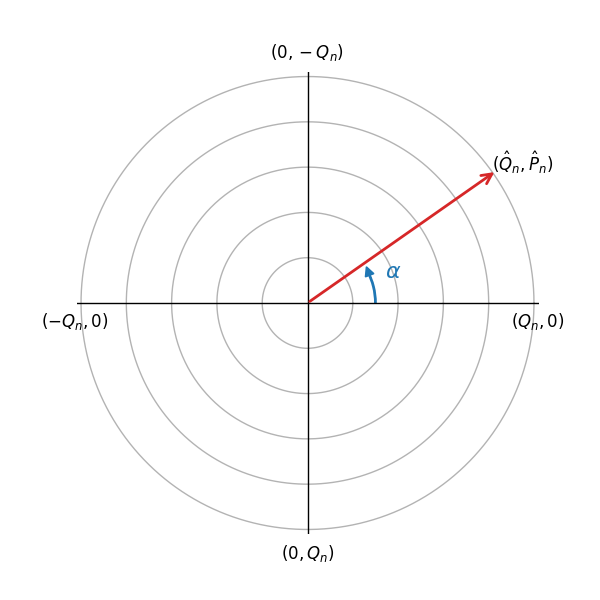

In [ ]:
import numpy as np
from matplotlib.patches import Arc
import matplotlib.pyplot as plt

# display dynamical plots
%matplotlib widget

# Use existing alpha if already defined; otherwise default to 35 degrees
alpha = globals().get("alpha", np.deg2rad(35.0))

# Accept either radians or degrees
alpha_rad = np.deg2rad(alpha) if np.abs(alpha) > 2 * np.pi else alpha
alpha_deg = np.rad2deg(alpha_rad)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")

# Circular gridlines
r_max = 5
theta = np.linspace(0, 2 * np.pi, 400)
for r in np.arange(1, r_max + 1):
    ax.plot(r * np.cos(theta), r * np.sin(theta), color="0.7", lw=1, zorder=-10)

# Cartesian axes
ax.axhline(0, color="black", lw=1)
ax.axvline(0, color="black", lw=1)

# Angle ray with arrowhead at the end
x_end = 1.02*r_max * np.cos(alpha_rad)
y_end = 1.02*r_max * np.sin(alpha_rad)
ax.annotate(
    "",
    xy=(x_end, y_end),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle="->", color="tab:red", lw=2, mutation_scale=18),
    zorder=3,
)

# Arc marking angle alpha from +x axis
arc_radius = 1.5
arc = Arc((0, 0), 2 * arc_radius, 2 * arc_radius, angle=0,
          theta1=0, theta2=0.8*alpha_deg, color="tab:blue", lw=2)
ax.add_patch(arc)

# Add an arrow on the arc indicating direction (increasing theta)
# choose a point along the arc (fraction of the total angle)
arrow_frac = 0.6
theta_arrow = arrow_frac * alpha_rad
x_a = arc_radius * np.cos(theta_arrow)
y_a = arc_radius * np.sin(theta_arrow)
# tangent direction for increasing theta is (-sin, cos)
arrow_len = 0.28
dx = arrow_len * -np.sin(theta_arrow)
dy = arrow_len *  np.cos(theta_arrow)
ax.arrow(x_a, y_a, dx, dy, width=0.0, length_includes_head=True,
         head_width=0.2, head_length=0.2, fc="tab:blue", ec="tab:blue", zorder=5)

# Label alpha on arc
label_angle = alpha_rad / 2
ax.text(
    1.8 * np.cos(label_angle),
    1.8 * np.sin(label_angle),
    r"$\alpha$",
    color="tab:blue",
    fontsize=16,
    zorder=5
)

# Cardinal angle labels
ax.text(r_max-0.5,    -0.4,         r"$(Q_n,0) $", ha="left",   va="center", fontsize=12)
ax.text(0,            r_max + 0.3,  r"$(0,-Q_n)$", ha="center", va="bottom", fontsize=12)
ax.text(-r_max+0.6,   -0.4,         r"$(-Q_n,0)$", ha="right",  va="center", fontsize=12)
ax.text(0,            -r_max - 0.3, r"$(0,Q_n) $", ha="center", va="top"   , fontsize=12)

ax.text(0.95*r_max, 0.68*r_max, r"$(\hat{Q}_n,\hat{P}_n) $", ha="center", va="top", fontsize=12)

ax.set_xlim(-r_max - 0.1, r_max + 0.1)
ax.set_ylim(-r_max - 0.1, r_max + 0.1)

# Remove outer box and numeric axis values
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

ax.grid(False)

#fig.savefig("tmp.png", bbox_inches="tight", pad_inches=0, dpi=450)

plt.show()